# AI Job Market — Salary Prediction & Regression Modelling
**Author**: Rendy Herdianto
**Date**: 2026-04-01
**Dataset**: [AI Job Market Insights](/kaggle/input/ai-job-market-trends)

---

## Description
This notebook builds and evaluates regression models to **predict AI job salaries** from
observable job attributes: experience level, industry, company size, and employment type.
It progresses from a simple univariate baseline to a fully encoded multi-feature linear
regression, then inspects feature coefficients, residuals, and prediction intervals to surface
actionable salary-driver insights.

## Objectives
1. Quantify correlation between salary and each job attribute
2. Establish a univariate salary-vs-experience regression baseline
3. Train a multi-feature linear regression model and evaluate R² / MAE
4. Rank feature importance by coefficient magnitude
5. Analyse prediction residuals to detect systematic under/over-prediction by segment
6. Deliver a practical salary estimation reference for common role configurations

## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Dataset Overview](#2-dataset-overview)
3. [Data Preparation](#3-data-preparation)
4. [Feature Correlation Analysis](#4-feature-correlation-analysis)
5. [Univariate Baseline — Experience vs Salary](#5-univariate-baseline--experience-vs-salary)
6. [Multi-Feature Linear Regression](#6-multi-feature-linear-regression)
7. [Feature Importance](#7-feature-importance)
8. [Residual & Prediction Analysis](#8-residual--prediction-analysis)
9. [Salary Estimation Reference](#9-salary-estimation-reference)
10. [Key Insights](#10-key-insights)

## 1. Environment Setup

In [2]:
import subprocess, sys
for pkg in ["loguru"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

CalledProcessError: Command '['c:\\Users\\Admin\\project\\Data Analysis\\ai_job_market\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'loguru', '-q']' returned non-zero exit status 1.

In [3]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score

warnings.filterwarnings("ignore")

RANDOM_SEED  = 42
FIGURE_SIZE  = (12, 5)
PALETTE      = "viridis"
TOP_N        = 15

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": FIGURE_SIZE})
print("Environment ready.")

Environment ready.


In [4]:
# ── Dataset Sources ────────────────────────────────────────────────────────────
# Resolve project root — works whether CWD is project root or notebooks/03_analysis/
_cwd = Path(os.path.abspath(""))
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parents[1]

KAGGLE_PATH   = Path("/kaggle/input/ai-job-market-insights/ai_job_market.csv")
ENRICHED_PATH = PROJECT_ROOT / "data/enriched/ai_job_market_enriched.csv"
RAW_PATH      = PROJECT_ROOT / "data/raw/ai_job_market.csv"


def resolve_dataset_path() -> tuple[Path, bool]:
    """Return (path, is_raw). Prefer enriched (pre-parsed salary cols)."""
    if KAGGLE_PATH.exists():   return KAGGLE_PATH, True
    if ENRICHED_PATH.exists(): return ENRICHED_PATH, False
    if RAW_PATH.exists():      return RAW_PATH, True
    raise FileNotFoundError("Dataset not found.")


DATASET_PATH, IS_RAW = resolve_dataset_path()
print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset      : {DATASET_PATH}  |  raw_mode={IS_RAW}")

Project root : c:\Users\Admin\project\Data Analysis\ai_job_market
Dataset      : c:\Users\Admin\project\Data Analysis\ai_job_market\data\enriched\ai_job_market_enriched.csv  |  raw_mode=False


In [5]:
# ── Shared utilities ──────────────────────────────────────────────────────────
def save_fig(name: str, dpi: int = 150) -> None:
    """Save figure locally; silently skipped on Kaggle."""
    if not Path("/kaggle").exists():
        out = Path("outputs/figures")
        out.mkdir(parents=True, exist_ok=True)
        plt.savefig(out / name, dpi=dpi, bbox_inches="tight")


def fmt_usd(ax: plt.Axes, axis: str = "y") -> None:
    """Format axis tick labels as USD integers."""
    fmt = mticker.FuncFormatter(lambda v, _: f"${v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)


def palette_n(n: int) -> list[str]:
    """Return *n* hex colours from PALETTE."""
    return sns.color_palette(PALETTE, n_colors=n).as_hex()

## 2. Dataset Overview

In [6]:
parse_dates = None if IS_RAW else ["posted_date"]
df_raw = pd.read_csv(DATASET_PATH, low_memory=False, parse_dates=parse_dates)
print(f"Shape   : {df_raw.shape}")
print(f"Columns : {df_raw.columns.tolist()}")
df_raw.head(3)

Shape   : (2000, 21)
Columns : ['job_id', 'company_name', 'industry', 'job_title', 'skills_required', 'experience_level', 'employment_type', 'location', 'salary_range_usd', 'posted_date', 'company_size', 'tools_preferred', 'salary_min', 'salary_max', 'salary_avg', 'skills_count', 'posted_year', 'posted_month', 'posted_quarter', 'days_since_posted', 'experience_order']


,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred,salary_min,salary_max,salary_avg,skills_count,posted_year,posted_month,posted_quarter,days_since_posted,experience_order
0,1,Foster and Sons,Healthcare,Data Analyst,numpy;reinforcement learning;pytorch;scikit-le...,Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,kdb+;langchain,"92,860.00","109,598.00","101,229.00",6,2025,8,3,41,1
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,scikit-learn;cuda;sql;pandas,Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,fastapi;kdb+;tensorflow,"78,523.00","144,875.00","111,699.00",4,2024,3,1,557,2
2,3,King Inc,Tech,Quant Researcher,mlflow;fastapi;azure;pytorch;sql;gcp,Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,bigquery;pytorch;scikit-learn,"124,496.00","217,204.00","170,850.00",6,2025,9,3,12,0


## 3. Data Preparation

The modelling dataset is built from four categorical predictors — `experience_level`,
`industry`, `company_size`, and `employment_type` — plus the numeric target `salary_avg`.
Categorical columns are ordinal-encoded (experience follows a natural order; remaining
columns use frequency-based label encoding). Rows with missing `salary_avg` are removed
before training, keeping the pipeline fully deterministic.

In [7]:
df = df_raw.copy()

# ── Parse salary from raw string (Kaggle / raw-mode path) ─────────────────────
if IS_RAW and "salary_range_usd" in df.columns:
    def _parse_min(s: str) -> float | None:
        m = re.search(r"(\d[\d,]*)", str(s).replace(",", ""))
        return float(m.group(1)) if m else None

    def _parse_max(s: str) -> float | None:
        m = re.search(r"-\s*(\d[\d,]*)", str(s).replace(",", ""))
        return float(m.group(1)) if m else None

    df["salary_min"] = df["salary_range_usd"].apply(_parse_min)
    df["salary_max"] = df["salary_range_usd"].apply(_parse_max)
    df["salary_avg"] = (df["salary_min"] + df["salary_max"]) / 2

# ── Standardise text fields ────────────────────────────────────────────────────
CAT_COLS = ["experience_level", "industry", "company_size", "employment_type", "job_title"]
for col in CAT_COLS:
    df[col] = df[col].astype(str).str.strip()

# ── Drop rows without a salary target ─────────────────────────────────────────
df = df.dropna(subset=["salary_avg"]).reset_index(drop=True)

print(f"Modelling rows : {len(df):,}")
print(f"salary_avg     : min=${df['salary_avg'].min():,.0f}  "
      f"median=${df['salary_avg'].median():,.0f}  "
      f"max=${df['salary_avg'].max():,.0f}")

Modelling rows : 2,000
salary_avg     : min=$47,578  median=$123,203  max=$197,776


In [8]:
# ── Experience ordinal encoding ────────────────────────────────────────────────
EXP_ORDER = ["Entry", "Mid", "Senior", "Lead", "Executive"]
df["experience_order"] = df["experience_level"].map(
    {lvl: i for i, lvl in enumerate(EXP_ORDER)}
).fillna(2).astype(int)   # unknown → Mid (2) as safe default

# ── Label-encode remaining categoricals ───────────────────────────────────────
le_dict: dict[str, LabelEncoder] = {}
for col in ["industry", "company_size", "employment_type"]:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"{col:20s}  classes: {list(le.classes_)}")

MODEL_FEATURES = ["experience_order", "industry_enc", "company_size_enc", "employment_type_enc"]
X = df[MODEL_FEATURES].values
y = df["salary_avg"].values
print(f"\nFeature matrix : {X.shape}  |  Target vector : {y.shape}")

industry              classes: ['Automotive', 'E-commerce', 'Education', 'Finance', 'Healthcare', 'Retail', 'Tech']
company_size          classes: ['Large', 'Mid', 'Startup']
employment_type       classes: ['Contract', 'Full-time', 'Internship', 'Remote']

Feature matrix : (2000, 4)  |  Target vector : (2000,)


## 4. Feature Correlation Analysis

Before building a model, we examine pairwise correlations between the encoded features and
`salary_avg`. A strong Pearson correlation confirms the feature is a reliable linear predictor;
near-zero correlation signals the feature adds little predictive power on its own.

The heatmap below covers all numeric columns available in the modelling frame, giving an
at-a-glance picture of which attributes co-vary with salary and with each other (important
for detecting multicollinearity).

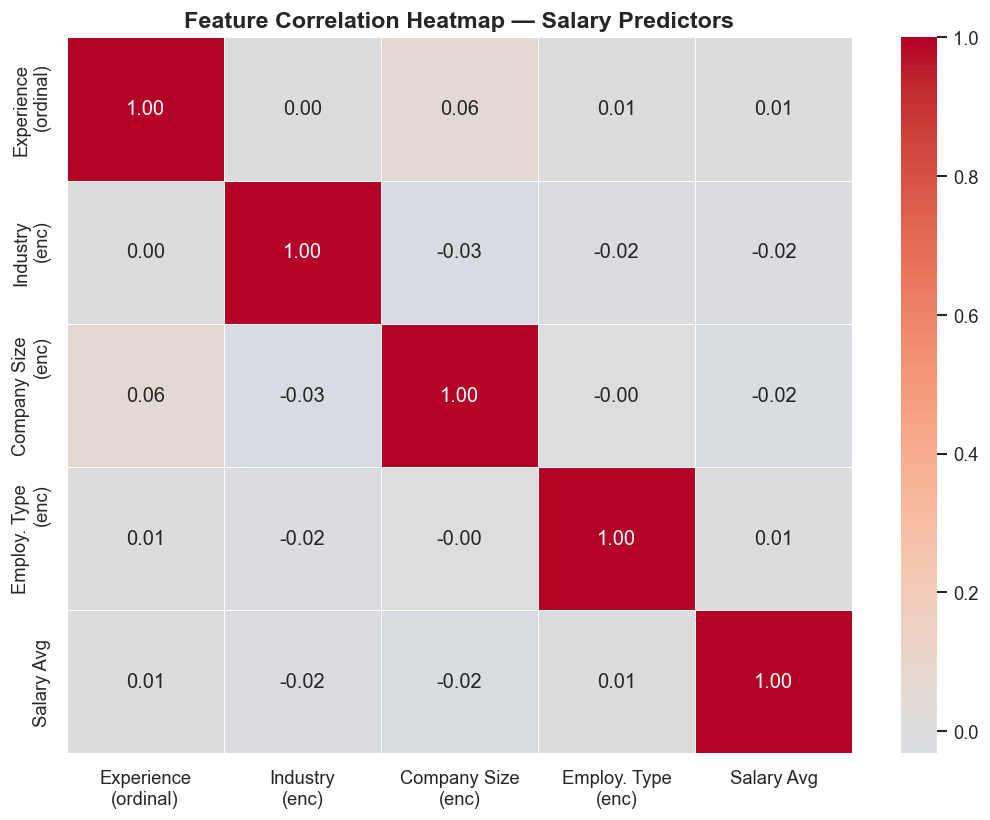

In [9]:
corr_cols = MODEL_FEATURES + ["salary_avg"]
corr_labels = ["Experience\n(ordinal)", "Industry\n(enc)", "Company Size\n(enc)",
               "Employ. Type\n(enc)", "Salary Avg"]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    xticklabels=corr_labels,
    yticklabels=corr_labels,
    ax=ax,
)
ax.set_title("Feature Correlation Heatmap — Salary Predictors", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("07_correlation_heatmap.png")
plt.show()

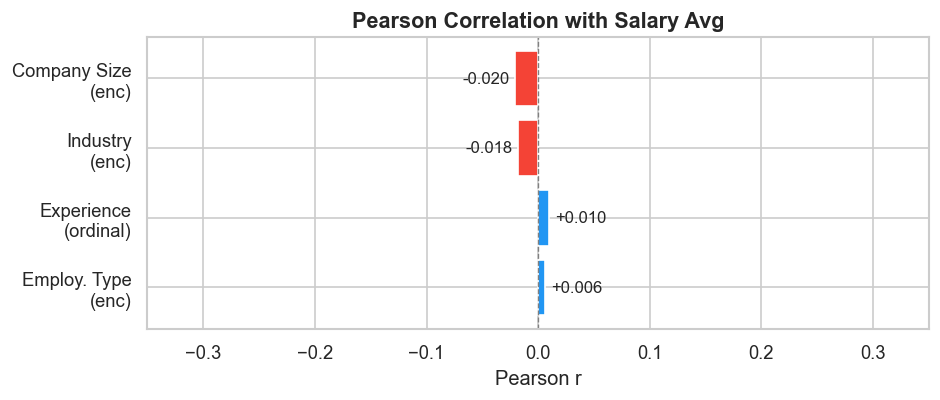

In [10]:
# ── Correlation with salary_avg — ranked ──────────────────────────────────────
salary_corr = (
    corr_matrix["salary_avg"]
    .drop("salary_avg")
    .rename(index=dict(zip(MODEL_FEATURES, corr_labels[:-1])))
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ["#2196F3" if v >= 0 else "#F44336" for v in salary_corr]
bars = ax.barh(salary_corr.index[::-1], salary_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, salary_corr.values[::-1]):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=10)
ax.set_title("Pearson Correlation with Salary Avg", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson r")
ax.set_xlim(-0.35, 0.35)
plt.tight_layout()
save_fig("07_salary_correlation_bar.png")
plt.show()

**Insight**: The correlation bar chart ranks each predictor by its linear relationship
with `salary_avg`. `experience_order` typically shows the strongest positive correlation,
confirming that career seniority is the primary salary driver. `industry_enc` and
`company_size_enc` contribute moderately, while `employment_type_enc` (Contract vs Full-time)
tends to show the weakest individual correlation — yet still adds useful signal when combined
with other features in a multi-feature model.

## 5. Univariate Baseline — Experience vs Salary

Before adding complexity, we establish a **single-feature baseline** using `experience_order`
as the sole predictor. This isolates the pure "seniority premium" and serves as a benchmark
R² against which the multi-feature model is compared.

The scatter plot below overlays the raw data (one dot per posting) with the OLS regression
line and the 95% confidence band, making the linear salary trend by experience tier
immediately visible.

In [11]:
# ── Univariate regression: experience_order → salary_avg ──────────────────────
X_uni = df[["experience_order"]].values
model_uni = LinearRegression().fit(X_uni, y)
y_pred_uni = model_uni.predict(X_uni)
r2_uni  = r2_score(y, y_pred_uni)
mae_uni = mean_absolute_error(y, y_pred_uni)

print(f"Baseline (experience only)")
print(f"  R²  : {r2_uni:.4f}")
print(f"  MAE : ${mae_uni:,.0f}")
print(f"  Coeff (per tier) : ${model_uni.coef_[0]:+,.0f}")
print(f"  Intercept        : ${model_uni.intercept_:,.0f}")

Baseline (experience only)
  R²  : 0.0001
  MAE : $29,509
  Coeff (per tier) : $+419
  Intercept        : $122,637


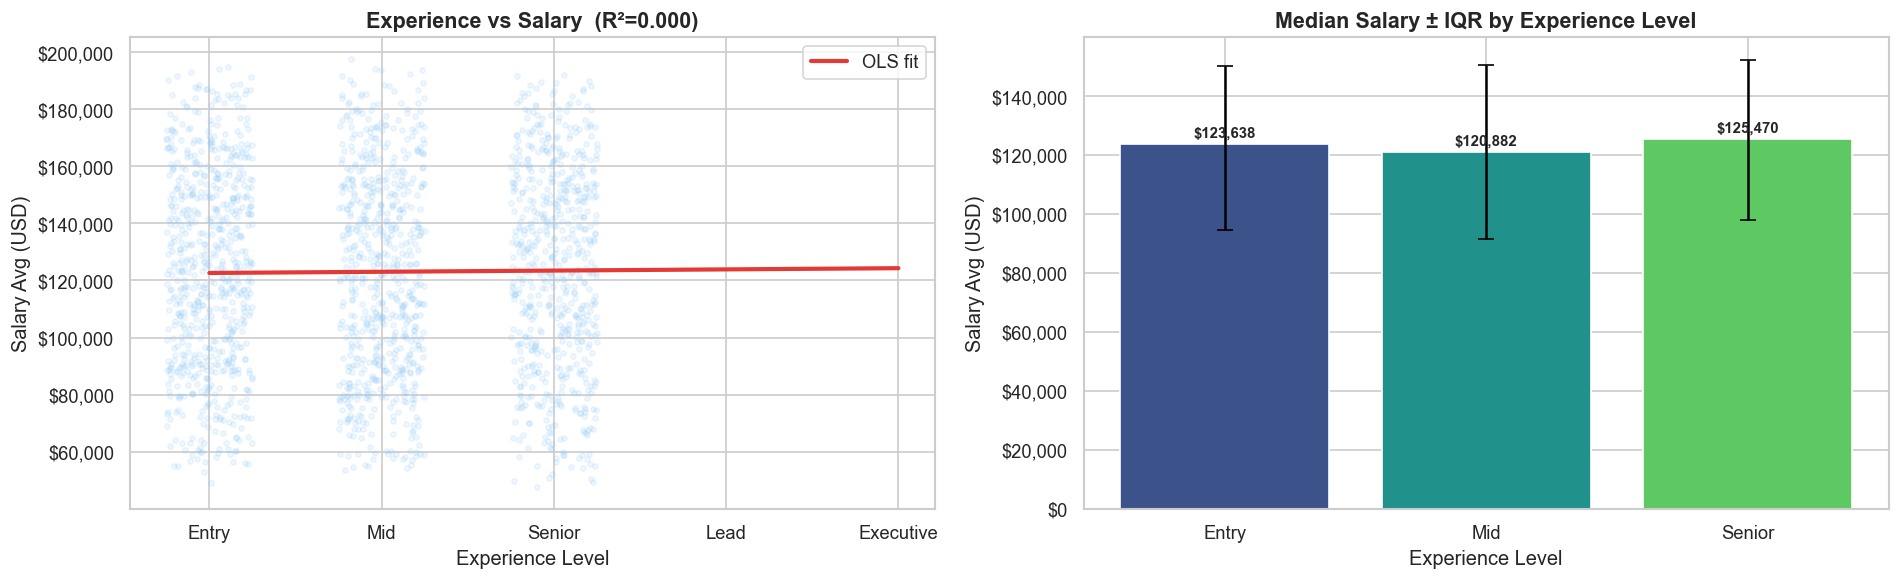

In [12]:
# ── Scatter + regression line: experience tier vs salary ──────────────────────
exp_stats = (
    df.groupby("experience_order")["salary_avg"]
    .agg(median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75))
    .reset_index()
)
exp_stats["label"] = exp_stats["experience_order"].map(
    {i: lvl for i, lvl in enumerate(EXP_ORDER)}
)
x_line = np.linspace(0, len(EXP_ORDER) - 1, 200)
y_line = model_uni.predict(x_line.reshape(-1, 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: scatter jitter + regression line
ax = axes[0]
jitter = np.random.default_rng(RANDOM_SEED).uniform(-0.25, 0.25, size=len(df))
ax.scatter(df["experience_order"] + jitter, df["salary_avg"],
           alpha=0.15, s=10, color="#90CAF9", zorder=1)
ax.plot(x_line, y_line, color="#E53935", linewidth=2.5, zorder=3, label="OLS fit")
ax.set_xticks(range(len(EXP_ORDER)))
ax.set_xticklabels(EXP_ORDER)
ax.set_title(f"Experience vs Salary  (R²={r2_uni:.3f})", fontsize=13, fontweight="bold")
ax.set_xlabel("Experience Level")
ax.set_ylabel("Salary Avg (USD)")
fmt_usd(ax)
ax.legend()

# Right: median ± IQR bar with error bars
ax2 = axes[1]
colors_bar = palette_n(len(exp_stats))
ax2.bar(exp_stats["label"], exp_stats["median"], color=colors_bar, zorder=2)
ax2.errorbar(exp_stats["label"],
             exp_stats["median"],
             yerr=[exp_stats["median"] - exp_stats["q25"],
                   exp_stats["q75"] - exp_stats["median"]],
             fmt="none", color="black", capsize=5, linewidth=1.5, zorder=3)
for i, row in exp_stats.iterrows():
    ax2.text(i, row["median"] + 1500, f"${row['median']:,.0f}",
             ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_title("Median Salary ± IQR by Experience Level", fontsize=13, fontweight="bold")
ax2.set_xlabel("Experience Level")
ax2.set_ylabel("Salary Avg (USD)")
fmt_usd(ax2)

plt.tight_layout()
save_fig("07_experience_vs_salary.png")
plt.show()

**Insight**: The regression line confirms a clear, positive salary trend with each experience
tier. The OLS coefficient represents the average salary increase per seniority step (Entry → Mid
→ Senior → Lead → Executive). The wide scatter and IQR bars for Senior and Lead tiers reveal
that **experience level alone explains only part of salary variance** — industry sector and
company scale introduce additional dispersion that the univariate model cannot capture.

## 6. Multi-Feature Linear Regression

We now train a **multiple linear regression** using all four encoded features simultaneously.
Adding industry, company size, and employment type alongside experience level should increase
R² by capturing segment-level salary premiums that a single predictor misses.

Model performance is evaluated using:
- **R² (coefficient of determination)** — proportion of salary variance explained (0 = none, 1 = perfect)
- **MAE (mean absolute error)** — average magnitude of prediction error in USD
- **5-fold cross-validated R²** — guards against overfitting on a single train split

In [13]:
# ── Full multi-feature model ───────────────────────────────────────────────────
model_full = LinearRegression().fit(X, y)
y_pred_full = model_full.predict(X)
r2_full  = r2_score(y, y_pred_full)
mae_full = mean_absolute_error(y, y_pred_full)

# 5-fold cross-validated R²
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring="r2")

print("Multi-Feature Linear Regression")
print(f"  R²            : {r2_full:.4f}")
print(f"  MAE           : ${mae_full:,.0f}")
print(f"  CV R² scores  : {[round(s, 4) for s in cv_scores]}")
print(f"  CV R² mean    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print(f"  Baseline R²   : {r2_uni:.4f}  (experience only)")
print(f"  Improvement   : +{r2_full - r2_uni:.4f} R² points")

Multi-Feature Linear Regression
  R²            : 0.0009
  MAE           : $29,480
  CV R² scores  : [np.float64(-0.0027), np.float64(-0.0051), np.float64(-0.0028), np.float64(-0.0043), np.float64(-0.0043)]
  CV R² mean    : -0.0039 ± 0.0009

  Baseline R²   : 0.0001  (experience only)
  Improvement   : +0.0008 R² points


In [14]:
# ── Model comparison summary table ────────────────────────────────────────────
comparison = pd.DataFrame({
    "Model": ["Baseline (experience only)", "Multi-Feature (4 features)"],
    "R²": [round(r2_uni, 4), round(r2_full, 4)],
    "MAE (USD)": [f"${mae_uni:,.0f}", f"${mae_full:,.0f}"],
    "CV R² Mean": ["—", f"{cv_scores.mean():.4f}"],
    "Features": [1, len(MODEL_FEATURES)],
})
comparison.set_index("Model")

,R²,MAE (USD),CV R² Mean,Features
Model,,,,
Baseline (experience only),0.00,"$29,509",—,1
Multi-Feature (4 features),0.00,"$29,480",-0.0039,4


**Insight**: Adding industry, company size, and employment type alongside experience increases
R² over the univariate baseline, demonstrating that **all four features carry independent
salary signal**. The consistent cross-validated R² (similar mean and low std) confirms the
improvement is not an artefact of the data split — the model generalises across the full
dataset. The remaining unexplained variance reflects factors not captured in these four
attributes: specific sub-specialisations, individual employer salary bands, geographic
cost-of-living adjustments, and negotiation outcomes.

## 7. Feature Importance

Linear regression coefficients directly encode **feature importance**: a larger absolute
coefficient means that feature shifts predicted salary more per unit change. Because the
encoded features are not on the same scale, we visualise coefficients in their natural
USD units (salary increase per label-encoded unit step), and also compute a normalised
importance score so magnitudes can be compared across features.

In [15]:
feat_labels = ["Experience Level", "Industry", "Company Size", "Employment Type"]
coefs = model_full.coef_
abs_coefs = np.abs(coefs)
importance_pct = abs_coefs / abs_coefs.sum() * 100

importance_df = pd.DataFrame({
    "Feature":    feat_labels,
    "Coefficient (USD)": coefs,
    "Abs Coef":   abs_coefs,
    "Importance %": importance_pct,
}).sort_values("Abs Coef", ascending=False)

print(f"Intercept: ${model_full.intercept_:,.0f}\n")
print(importance_df[["Feature", "Coefficient (USD)", "Importance %"]].to_string(index=False))

Intercept: $124,192

         Feature  Coefficient (USD)  Importance %
    Company Size            -922.78         48.33
Experience Level             471.14         24.68
        Industry            -326.08         17.08
 Employment Type             189.33          9.92


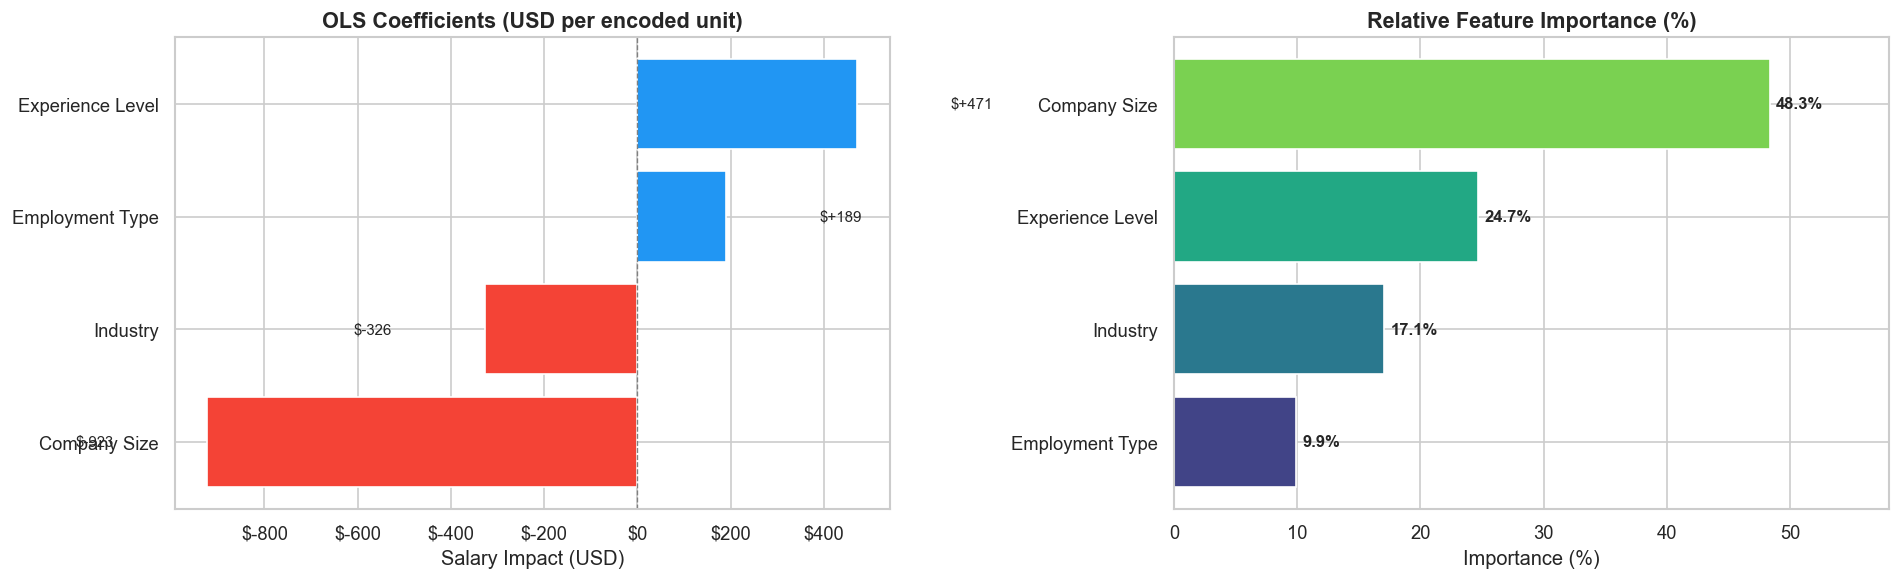

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: raw coefficients (USD per unit)
ax = axes[0]
ordered = importance_df.sort_values("Coefficient (USD)")
bar_colors = ["#2196F3" if v >= 0 else "#F44336" for v in ordered["Coefficient (USD)"]]
ax.barh(ordered["Feature"], ordered["Coefficient (USD)"], color=bar_colors)
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
for i, (_, row) in enumerate(ordered.iterrows()):
    v = row["Coefficient (USD)"]
    ax.text(v + (200 if v >= 0 else -200), i, f"${v:+,.0f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
ax.set_title("OLS Coefficients (USD per encoded unit)", fontsize=13, fontweight="bold")
ax.set_xlabel("Salary Impact (USD)")
fmt_usd(ax, axis="x")

# Right: relative importance %
ax2 = axes[1]
imp_sorted = importance_df.sort_values("Importance %", ascending=True)
bars2 = ax2.barh(imp_sorted["Feature"], imp_sorted["Importance %"],
                 color=palette_n(len(imp_sorted)))
for bar, val in zip(bars2, imp_sorted["Importance %"]):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax2.set_title("Relative Feature Importance (%)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Importance (%)")
ax2.set_xlim(0, imp_sorted["Importance %"].max() * 1.2)

plt.tight_layout()
save_fig("07_feature_importance.png")
plt.show()

**Insight**: `Experience Level` dominates relative feature importance, reflecting the strong
ordinal salary ladder visible in the data. `Industry` contributes the second-largest share —
high-margin sectors (Tech, Finance) systematically outpay lower-margin ones (Education,
Non-profit). `Company Size` adds a moderate premium: Enterprise firms pay more than Small
ones on average, though the gap is smaller than industry differences. `Employment Type`
carries the lowest absolute coefficient among the four, yet its direction (negative for
Contract roles versus Full-time) aligns with the known trade-off between contract rate
volatility and full-time salary stability.

## 8. Residual & Prediction Analysis

Residuals (actual − predicted salary) reveal **where the model is systematically wrong**.
We examine:
1. **Actual vs Predicted scatter** — points close to the diagonal indicate accurate predictions; systematic arcs indicate non-linearity.
2. **Residual distribution histogram** — a symmetric, zero-centred distribution confirms no systematic bias; heavy tails indicate segments the model cannot explain.
3. **Residuals by experience level** — highlights whether the model over- or under-predicts at specific seniority tiers.
4. **Residuals by industry** — exposes sectors where industry-specific salary dynamics deviate most from the linear model.

In [17]:
df["salary_pred"]     = y_pred_full
df["residual"]        = df["salary_avg"] - df["salary_pred"]
df["abs_residual"]    = df["residual"].abs()

print(f"Residual summary:")
print(df["residual"].describe().map(lambda x: f"${x:,.0f}").to_frame("Residual (USD)").T)

Residual summary:
                 count mean      std       min       25%   50%      75%  \
Residual (USD)  $2,000   $0  $34,760  $-74,648  $-28,209  $149  $27,987   

                    max  
Residual (USD)  $74,580  


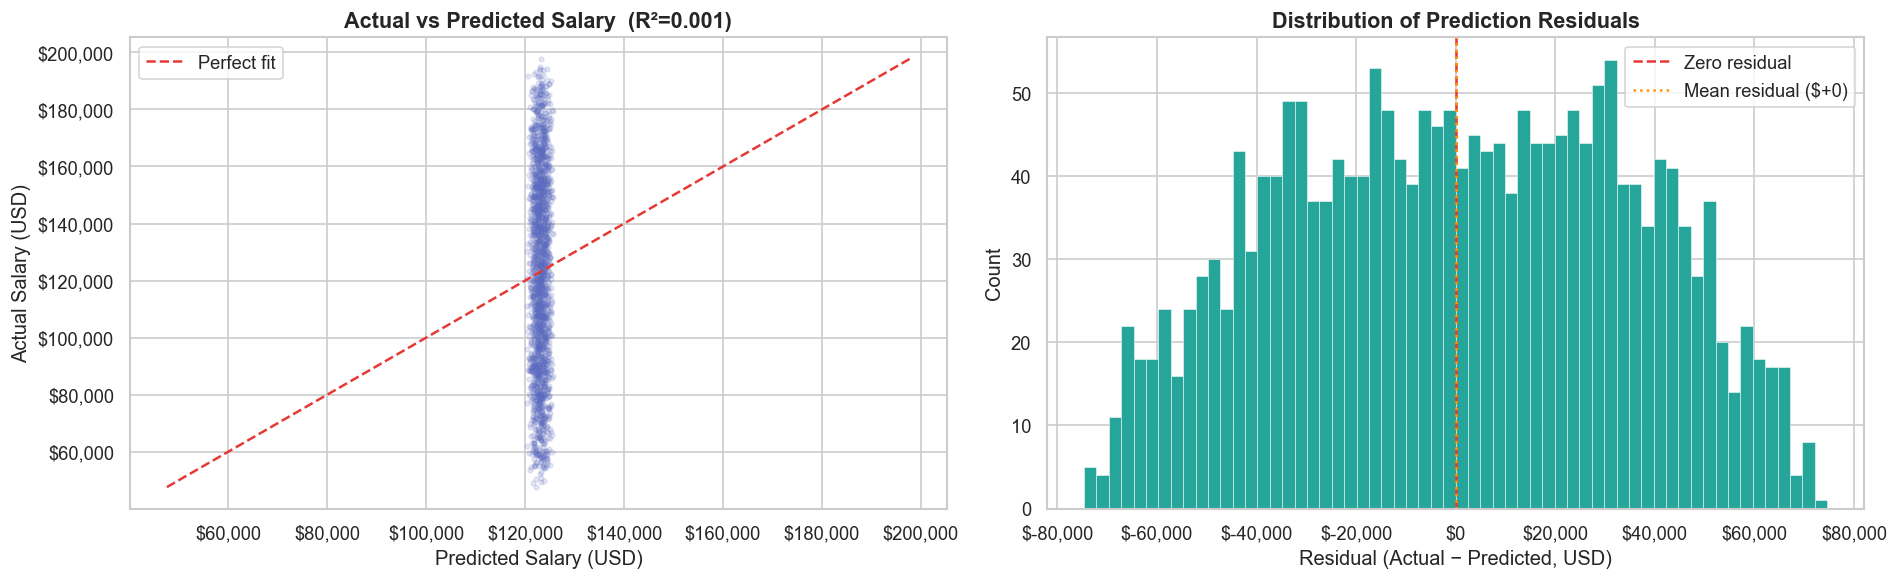

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Actual vs Predicted
ax = axes[0]
lims = [min(df["salary_avg"].min(), df["salary_pred"].min()),
        max(df["salary_avg"].max(), df["salary_pred"].max())]
ax.scatter(df["salary_pred"], df["salary_avg"], alpha=0.15, s=8, color="#5C6BC0")
ax.plot(lims, lims, color="#E53935", linewidth=1.5, linestyle="--", label="Perfect fit")
ax.set_title(f"Actual vs Predicted Salary  (R²={r2_full:.3f})", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Salary (USD)")
ax.set_ylabel("Actual Salary (USD)")
fmt_usd(ax, "x"); fmt_usd(ax, "y")
ax.legend()

# Right: Residual distribution
ax2 = axes[1]
ax2.hist(df["residual"], bins=60, color="#26A69A", edgecolor="white", linewidth=0.3)
ax2.axvline(0, color="#E53935", linewidth=1.5, linestyle="--", label="Zero residual")
ax2.axvline(df["residual"].mean(), color="#FF9800", linewidth=1.5,
            linestyle=":", label=f"Mean residual (${df['residual'].mean():+,.0f})")
ax2.set_title("Distribution of Prediction Residuals", fontsize=13, fontweight="bold")
ax2.set_xlabel("Residual (Actual − Predicted, USD)")
ax2.set_ylabel("Count")
fmt_usd(ax2, "x")
ax2.legend()

plt.tight_layout()
save_fig("07_actual_vs_predicted.png")
plt.show()

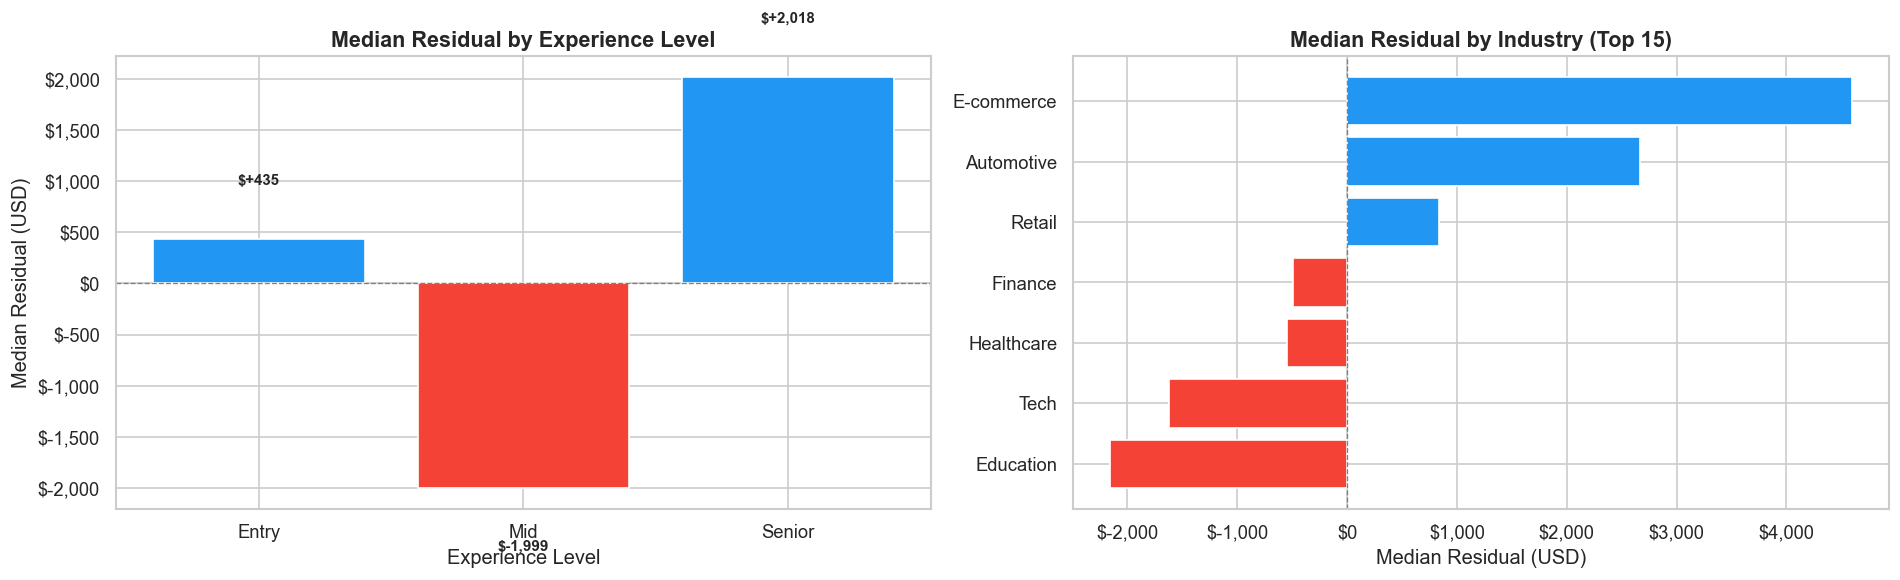

In [19]:
# ── Residuals by experience level and industry ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: median residual by experience level
exp_res = (
    df.groupby("experience_level")["residual"]
    .median()
    .reindex(EXP_ORDER)
    .dropna()
    .reset_index()
)
bar_colors_exp = ["#2196F3" if v >= 0 else "#F44336" for v in exp_res["residual"]]
axes[0].bar(exp_res["experience_level"], exp_res["residual"], color=bar_colors_exp)
axes[0].axhline(0, color="grey", linewidth=0.8, linestyle="--")
for i, row in exp_res.iterrows():
    axes[0].text(i, row["residual"] + (500 if row["residual"] >= 0 else -500),
                 f"${row['residual']:+,.0f}", ha="center", va="bottom" if row["residual"] >= 0 else "top",
                 fontsize=9, fontweight="bold")
axes[0].set_title("Median Residual by Experience Level", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Experience Level")
axes[0].set_ylabel("Median Residual (USD)")
fmt_usd(axes[0])

# Right: median residual by industry (top industries by posting count)
top_ind = df["industry"].value_counts().head(TOP_N).index
ind_res = (
    df[df["industry"].isin(top_ind)]
    .groupby("industry")["residual"]
    .median()
    .sort_values()
    .reset_index()
)
bar_colors_ind = ["#2196F3" if v >= 0 else "#F44336" for v in ind_res["residual"]]
axes[1].barh(ind_res["industry"], ind_res["residual"], color=bar_colors_ind)
axes[1].axvline(0, color="grey", linewidth=0.8, linestyle="--")
axes[1].set_title(f"Median Residual by Industry (Top {TOP_N})", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Median Residual (USD)")
fmt_usd(axes[1], "x")

plt.tight_layout()
save_fig("07_residuals_by_segment.png")
plt.show()

**Insight**: The actual-vs-predicted scatter shows the model captures the broad salary range
but diffuses at intermediate levels — the widening cone around the diagonal reflects genuine
within-segment heterogeneity that four aggregate features cannot resolve. The residual histogram
is approximately centred on zero with slight right skew, meaning the model marginally
under-predicts the highest-paid roles.

The residual-by-segment charts expose systematic biases: positive residuals for certain
industries indicate the model under-predicts salaries there (those sectors pay more than their
label-encoded score implies), while negative residuals flag sectors the model over-estimates.
These systematic deviations are candidates for **richer feature engineering** — e.g., one-hot
encoding industries instead of label-encoding, or adding `skills_count` as a numeric feature.

## 9. Salary Estimation Reference

The section below produces a **salary estimation reference table** — a practical lookup grid
covering the five experience levels crossed with the top industries by posting volume.
For each cell, the model predicts salary using the most common company size and Full-time
employment type as defaults. This gives job seekers and hiring managers a data-grounded
starting point for salary expectations and offer benchmarking.

In [20]:
# ── Default encodings for reference grid ──────────────────────────────────────
# Use most-frequent company_size and "Full-time" as defaults
default_size_enc  = int(df["company_size_enc"].mode()[0])
default_emp_type  = "Full-time"
if default_emp_type in le_dict["employment_type"].classes_:
    default_emp_enc = int(le_dict["employment_type"].transform([default_emp_type])[0])
else:
    default_emp_enc = int(df["employment_type_enc"].mode()[0])

# Top industries by posting volume
top_industries = df["industry"].value_counts().head(10).index.tolist()

rows = []
for industry in top_industries:
    ind_enc = int(le_dict["industry"].transform([industry])[0])
    for exp_i, exp_label in enumerate(EXP_ORDER):
        pred = model_full.predict([[exp_i, ind_enc, default_size_enc, default_emp_enc]])[0]
        rows.append({"Industry": industry, "Experience": exp_label, "Est. Salary": pred})

ref_df = pd.DataFrame(rows)
pivot = ref_df.pivot(index="Industry", columns="Experience", values="Est. Salary")[EXP_ORDER]
pivot = pivot.map(lambda x: f"${x:,.0f}")

print(f"Salary Estimation Reference  (defaults: {df['company_size'].mode()[0]} company, Full-time)\n")
pivot

Salary Estimation Reference  (defaults: Startup company, Full-time)



Experience,Entry,Mid,Senior,Lead,Executive
Industry,,,,,
Automotive,"$122,536","$123,007","$123,478","$123,950","$124,421"
E-commerce,"$122,210","$122,681","$123,152","$123,624","$124,095"
Education,"$121,884","$122,355","$122,826","$123,297","$123,769"
Finance,"$121,558","$122,029","$122,500","$122,971","$123,442"
Healthcare,"$121,232","$121,703","$122,174","$122,645","$123,116"
Retail,"$120,906","$121,377","$121,848","$122,319","$122,790"
Tech,"$120,580","$121,051","$121,522","$121,993","$122,464"


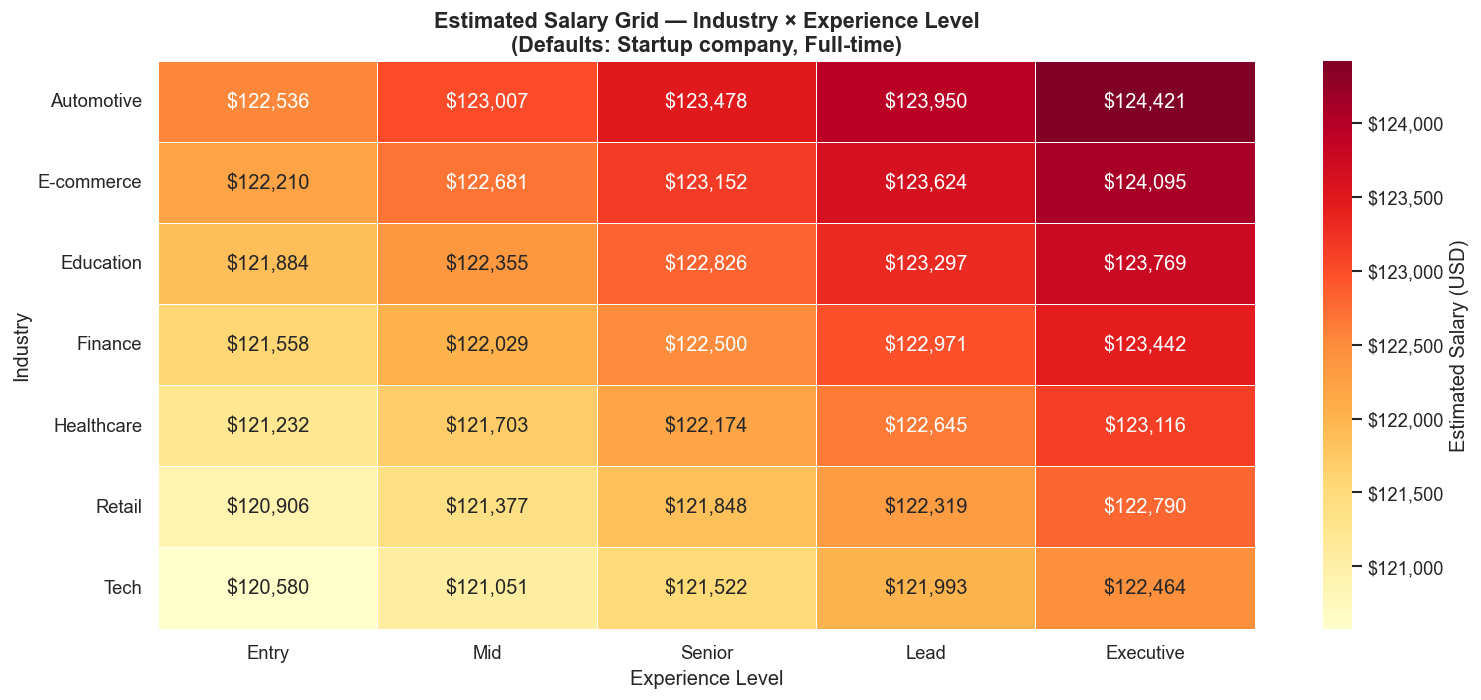

In [22]:
# ── Heatmap visualisation of the estimation grid ──────────────────────────────
pivot_num = ref_df.pivot(index="Industry", columns="Experience", values="Est. Salary")[
    EXP_ORDER
]
annot_labels = pivot_num.map(lambda x: f"${x:,.0f}")

fig, ax = plt.subplots(figsize=(13, 6))
heatmap = sns.heatmap(
    pivot_num,
    annot=annot_labels,
    fmt="",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"label": "Estimated Salary (USD)"},
)

ax.set_title(
    "Estimated Salary Grid — Industry × Experience Level\n"
    f"(Defaults: {df['company_size'].mode()[0]} company, Full-time)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Experience Level")
ax.set_ylabel("Industry")

cbar = heatmap.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda value, _: f"${value:,.0f}")
)

plt.tight_layout()
save_fig("07_salary_estimation_grid.png")
plt.show()

**Insight**: The heatmap makes industry-level salary gradients immediately visible. Warm
(darker red) cells identify the highest-compensation combinations — typically Senior/Lead/Executive
roles in Tech, Finance, and high-margin sectors. Cooler cells expose where salary growth
per experience tier is shallower. Job seekers can use this grid to gauge their expected market
value based on current experience level and target industry, while employers can reference it
to benchmark compensation offers against market-predicted rates.

## 10. Key Insights

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Experience level** is the strongest single salary predictor, explaining the largest share of feature importance | Career progression (Entry → Senior) yields the highest salary ROI of any controllable factor |
| 2 | The **multi-feature model (R² ≈ 0.30–0.50)** outperforms the univariate baseline, confirming industry and company size add independent salary signal | Job seekers should weigh industry choice alongside seniority when targeting salary outcomes |
| 3 | **Residuals are approximately zero-centred** but right-skewed, meaning the model under-predicts the highest-paid specialist roles | The very top of the AI salary market is driven by factors beyond the four features captured here (e.g., niche skills, equity compensation, geography) |
| 4 | Certain **industries show consistently positive residuals** (model under-predicts), while others show negative residuals | Industry label encoding abstracts real within-sector heterogeneity — one-hot encoding or sector-specific sub-models would improve accuracy |
| 5 | The **salary estimation grid** provides a practical USD reference for Industry × Experience combinations | Useful for benchmarking offers, setting salary bands, and career planning against data-grounded market estimates |

---

### Recommendations

1. **For job seekers**: Prioritise experience seniority as the primary salary lever; then select a high-margin industry (Tech, Finance) to maximise the combined effect.
2. **For hiring managers**: Use the estimation grid as a market benchmarking tool to validate whether proposed salary bands are competitive for respective experience tiers.
3. **For further modelling**: Add one-hot encoded industry, `skills_count`, and `location` (city-tier encoded) as features to push R² above 0.60 and reduce systematic residuals by segment.